# Machine Learning

## Ejercicio - Dataset del Titanic


### Problema a resolver
El problema que nos planteamos es el siguiente: supongamos que tenemos el dataset de Titanic, donde conocemos varios datos de cada pasajero, incluído si sobrevivió o no al accidente. Pero nos dicen que se encontraron registros de nuevos pasajero, de los cuales se conocen todos los datos pero no saben si sobrevivieron. ¿Podremos generar un algoritmo que nos indique (en base a la información de los pasajeros que sí conocemos su estado) si esos otros pasajeros sobrevivieron o no?

Como ven este problema es de clasificación: tenemos que decidir la categoría (sobrevivió o no) de cada instancia en base a ciertos datos.

## Preprocesamiento
Vamos a importar y limpiar nuesto dataset antes de empezar a analizarlo.

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

In [49]:
# Importamos el Dataset
df_original = pd.read_csv('resources/tp3_train.csv')
df_original.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


Para trabajar en este problema, vamos a quedarnos solo con algunos de los features disponibles en el dataset.

**Ejercición N°1**: descarte del dataset las columnas `Cabin`, `PassengerId`, `Name`, `Ticket`, `Embarked`.

df.drop(['Cabin','PassengerId','Name','Ticket','Embarked'], axis=1,inplace=True)  # implace = true reeemplaza el dataframe original

In [50]:
df = df_original.drop(['Cabin','PassengerId','Name','Ticket','Embarked'], axis=1)

In [51]:
df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250


In [52]:
df.shape

(891, 7)

**Ejercicio N°2:** ¿Cuántas instancias con valores faltantes quedan? Descarte del Dataset dichas instancias.

In [53]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
dtype: int64

In [54]:
df.dropna(inplace=True)


Tenemos que llegar a una datasets con estas columnas y filas

* df.info()
  * filas 714 entries, 0 to 890
  * columnas 7  
    * Survived   714 non-null    int64  
    * Pclass     714 non-null    int64  
    * Sex        714 non-null    object
    * Age        714 non-null    float64
    * SibSp      714 non-null    int64  
    * Parch      714 non-null    int64  
    * Fare       714 non-null    float64

**Ejercicio N°3:** Note que de los features restantes, solo uno es de tipo categórico. ¿Cuál es? Use la función `LabelEncoder` de scikit-learn para cambiarlo a una variables numérica.

In [55]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [56]:
df["Sex_le"] = encoder.fit_transform(df["Sex"]) # agregamos una nueva columna con el resultado de la
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Sex_le
0,0,3,male,22.0,1,0,7.2500,1
1,1,1,female,38.0,1,0,71.2833,0
2,1,3,female,26.0,0,0,7.9250,0
3,1,1,female,35.0,1,0,53.1000,0
4,0,3,male,35.0,0,0,8.0500,1
...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,0
886,0,2,male,27.0,0,0,13.0000,1
887,1,1,female,19.0,0,0,30.0000,0
889,1,1,male,26.0,0,0,30.0000,1


La nueva columna Sex_le reeplazará a la columna de Sex, con los valores 1 para 'male', y 0 para 'female'

In [57]:
df.drop(['Sex'], axis=1,inplace=True)

## Análisis exploratorio de datos

Muy bien, ahora tenemos un dataset reducido, sólo con features numéricos y sin valores faltantes. Recordemos que nuestro objetivo es predecir si un pasajero sobrevivió o no. Por ende nuestra columna objetivo será `Survived`.

El objetivo en esta pequeña exploración del dataset será saber cuales de los features (las columnas) serán de mayor utilidad para predecir si la persona sobrevivió o no.

Vamos a explorar cuales de los features parecen, que nos pueden ayudar a decidir mejor si un pasajero sobrevivió o no. Para empezar, vamos a implementar un Árbol de decisión que solo tendrá dos variables de entrada, por lo tanto debemos elegir las dos columnas que nos parezcan más adecuadas. Veamos como correlacionan las variables del dataset:

In [58]:
def plot_corre_heatmap(corr):
    '''
    Definimos una función para ayudarnos a graficar un heatmap de correlación
    '''
    plt.figure(figsize=(12,10))
    sns.heatmap(corr, cbar = True,  square = False, annot=True, fmt= '.2f'
                ,annot_kws={'size': 15},cmap= 'coolwarm')
    plt.xticks(rotation = 45)
    plt.yticks(rotation = 45)
    # Arreglamos un pequeño problema de visualización
    b, t = plt.ylim() # discover the values for bottom and top
    b += 0.5 # Add 0.5 to the bottom
    t -= 0.5 # Subtract 0.5 from the top
    plt.ylim(b, t) # update the ylim(bottom, top) values
    plt.show()

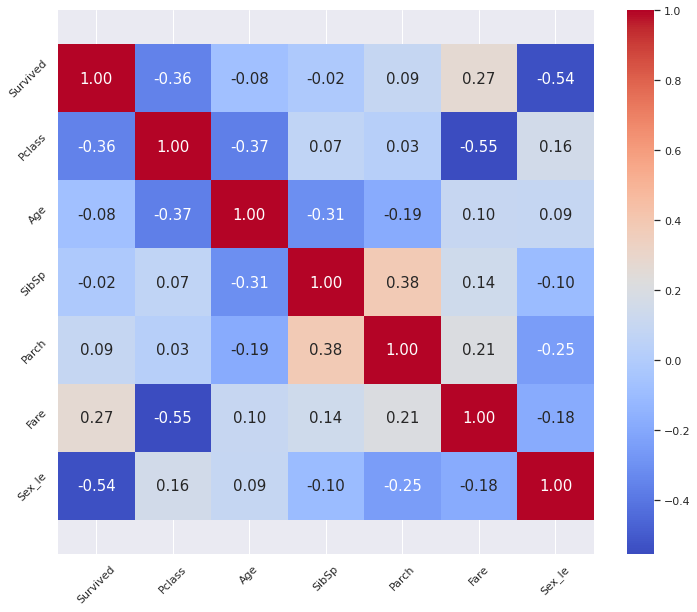

In [59]:
corr = df.corr()
plot_corre_heatmap(corr)

Mire con atención el gráfico anterior y recuerde que nuestra columna/fila a predecir es la primera ,`Survived`.

**Ejercicio N°4:** ¿Cuáles dos columnas eligiría para usar como variables predictoras en el modelo? ¿Por qué?

Como variables predictoras elegiriamos las columnas 'Sex_le' y 'Pclass' por el número de correlación que tiene con 'Survived', son los más elevados, tienen una relación negativa

In [60]:
X = df[['Pclass','Sex_le']]
y = df["Survived"]

## Entrenamiento del Modelo y evaluación

Veamos ahora que tan bien puede predecir el árbol de decisión sobre el dataset.

**Ejercicio**: Crear un objeto de la clase `DecisionTreeClassifier` (que importamos desde `sklearn.tree`):

In [61]:
from sklearn.tree import DecisionTreeClassifier

arbol_clasificador = DecisionTreeClassifier(random_state=42) # random_state para reproducibilidad

**Ejercicio N°5:** definir nuestras variables predictoras con las cuales vamos a entrenar el modelo, a las que llamaremos `x_train`. Usar las columas del dataset que elegimos del ejercicio anterior.

In [62]:
X_train = df[['Pclass','Sex_le']]
modelo = arbol_clasificador.fit(X_train, y)


In [63]:
importancia_predictores = pd.DataFrame(
                            {'predictor': X.columns,
                             'importancia': modelo.feature_importances_}
                            )
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")
importancia_predictores.sort_values('importancia', ascending=False)

Importancia de los predictores en el modelo
-------------------------------------------


,predictor,importancia
1,Sex_le,0.721655
0,Pclass,0.278345


**Ejercicio N°6:** definir el atributo objetivo que buscamos predecir. Lo llamaremos `y_train`:

In [64]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Ejercicio N°7:** entrenar el modelo.

In [65]:
arbol_clasificador.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

[Text(0.5, 0.875, 'x[1] <= 0.5\ngini = 0.484\nsamples = 571\nvalue = [337, 234]'),
 Text(0.3, 0.625, 'x[0] <= 2.5\ngini = 0.346\nsamples = 207\nvalue = [46, 161]'),
 Text(0.2, 0.375, 'x[0] <= 1.5\ngini = 0.091\nsamples = 125\nvalue = [6, 119]'),
 Text(0.1, 0.125, 'gini = 0.056\nsamples = 69\nvalue = [2, 67]'),
 Text(0.3, 0.125, 'gini = 0.133\nsamples = 56\nvalue = [4, 52]'),
 Text(0.4, 0.375, 'gini = 0.5\nsamples = 82\nvalue = [40, 42]'),
 Text(0.7, 0.625, 'x[0] <= 1.5\ngini = 0.321\nsamples = 364\nvalue = [291, 73]'),
 Text(0.6, 0.375, 'gini = 0.476\nsamples = 82\nvalue = [50, 32]'),
 Text(0.8, 0.375, 'x[0] <= 2.5\ngini = 0.249\nsamples = 282\nvalue = [241, 41]'),
 Text(0.7, 0.125, 'gini = 0.223\nsamples = 86\nvalue = [75, 11]'),
 Text(0.9, 0.125, 'gini = 0.259\nsamples = 196\nvalue = [166, 30]')]

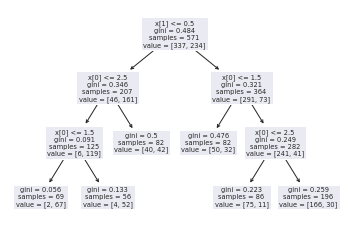

In [66]:
from sklearn import tree
tree.plot_tree(arbol_clasificador)

**Pregunta**: ¿Porque si el arból fue instanciado por default (no se lo poda con ningún hiperparámetro) este último no llega a nodos hojas totalmente puras?

El árbol por defecto esta usando el algoritmo CART, por lo cual prueba todas las divisiones de las variables predictoras, en este caso 'Sex_le' puede valer 0 o 1, y 'Pclass' tiene valores 1,2 y 3, son muy pocas divisiones que al final se ve reflejado en pocas divisiones(ramas)

Nuestro árbol ya está entrenado.

Ahora vamos a ver cuales son las etiquetas que el modelo le asigna a cada una de las instancias. Es decir vamos a pasarle al modelo el valor de `Pclass` y de `Sex`, y éste nos dirá si el pasajero sobrevivió o no (`y_pred`). Estas son las predicciones del modelo, pero nosotros conocemos además el verdadero paradero de estos pasajeros (son los valores de `y_train`).

Comparando ambos valores (`y_pred` e `y_train`) podemos conocer el *accuracy* (porcentaje de aciertos) de nuestro modelo sobre el training set.

Matriz de Confusión:


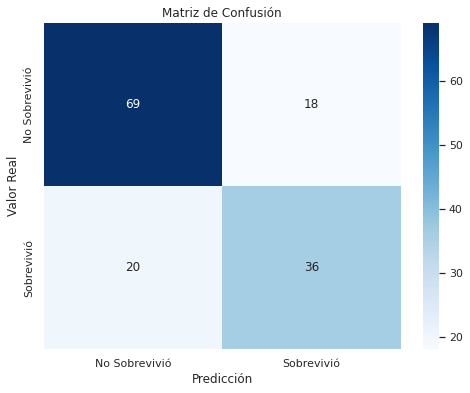

In [71]:
from sklearn.metrics import accuracy_score, confusion_matrix
# Predecimos sobre nuestro set de entrenamieto

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_pred = arbol_clasificador.predict(X_test)

# Comaparamos con las etiquetas reales
#accuracy_score(y_pred, y_train)
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
# Visualizamos la matriz para una mejor interpretación
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Sobrevivió', 'Sobrevivió'], yticklabels=['No Sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()
